# hierboost end-to-end: fit, interpret, evaluate

A worked walkthrough of `HierBoostClassifier`/`HierBoostRegressor` (`hierboost/estimator.py`)
on a real dataset: fit -> read the summary -> plot -> predict with uncertainty -> compare
against baselines.

**Under the hood**: a spike-and-slab GLM whose prior inclusion probability can optionally
be *boosted* by proximity to relevant domain groups, and whose raw features can optionally
be *decorrelated* into one shared latent per block first. Both are optional -- the plain
fit below is always available and the right place to start. See the repo README for the
full story.

**Dataset**: sklearn's Breast Cancer Wisconsin (569 samples, binary target). Its 30
features are 10 physical measurements x 3 statistics each (mean/error/worst) -- a real
correlated-triplet structure used later to demonstrate block-decorrelation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, roc_auc_score

from hierboost import HierBoostClassifier, HierBoostRegressor

%matplotlib inline
np.random.seed(0)


## 1. Load and prepare the data

Spike-and-slab puts a *shared* slab variance (`sigma2`) across all features, so
features need to be on comparable scales going in — standardize (fit the
scaler on the training split only, to avoid test-set leakage).


In [2]:
data = load_breast_cancer()
X, y = data.data, data.target  # y=1 is "benign" in sklearn's encoding
feature_names = list(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"train: {X_train_s.shape}, test: {X_test_s.shape}, positive rate: {y_train.mean():.2f}")


train: (426, 30), test: (143, 30), positive rate: 0.63


## 2. Plain spike-and-slab fit (no boosting, no decorrelation)

This is the baseline usage: pass `X`, `y`, get back posterior inclusion
probabilities and coefficients for every raw feature. `fit_method="em"` (the
default) is the fast, deterministic option — see the note on `"gibbs"` and
`"em_filter"` near the end for alternatives.


In [26]:
clf = HierBoostClassifier(fit_method="em")
clf.fit(X_train_s, y_train, feature_names=feature_names)
print(clf.summary(top_n=5))


HierBoostClassifier summary
Response:             binomial (n_trials=1)
Fit method:           em
Decorrelation:        none
Observations:         n=426
Features/blocks:      30
------------------------------------------------------------------------
Hyperparameters:      xi0=-2.0  xi1=0.0  kappa=100.0  nu=1.0  lam=1.0
sigma2 (slab var):    0.1923
PPL:                  21.9063
EMBFDR @ gamma=1.0:   0.0000
Selected (centroid):  0 / 30
------------------------------------------------------------------------
Top 5 of 30 features/blocks by inclusion probability:
name                 theta_hat      coef        se   [95% CI]
worst texture           0.0471   -0.7093    0.3327  [ -1.361,  -0.057]
worst radius            0.0394   -0.6565    0.4209  [ -1.482,   0.168]
worst concave points    0.0372   -0.6386    0.3953  [ -1.414,   0.136]
mean concave points     0.0329   -0.5988    0.4061  [ -1.395,   0.197]
worst perimeter         0.0314   -0.5824    0.4216  [ -1.409,   0.244]


### Reading the summary

- **`theta_hat`** -- posterior inclusion probability (0-1) per feature; read as a
  *relative ranking*, not an absolute cutoff.
- **`coef`/`se`/CI** -- the slab coefficient and its approximate SE (Laplace, or exact
  under `fit_method="gibbs"`).
- **`PPL`** -- in-sample fit quality; lower is better, mainly useful for comparing settings.
- **`EMBFDR`/"Selected (centroid)"** -- a hard FDR-controlled selection. With these
  defaults, `theta_hat` is spread thin across all 30 correlated features (none crosses
  0.5), so 0 clear the threshold here -- yet `.predict()` still works fine, since it
  always uses the full continuous `beta_` vector. For an actual sparse subset, use
  `fit_method="em_filter"` (shown later), which drops features rather than only shrinking
  them.


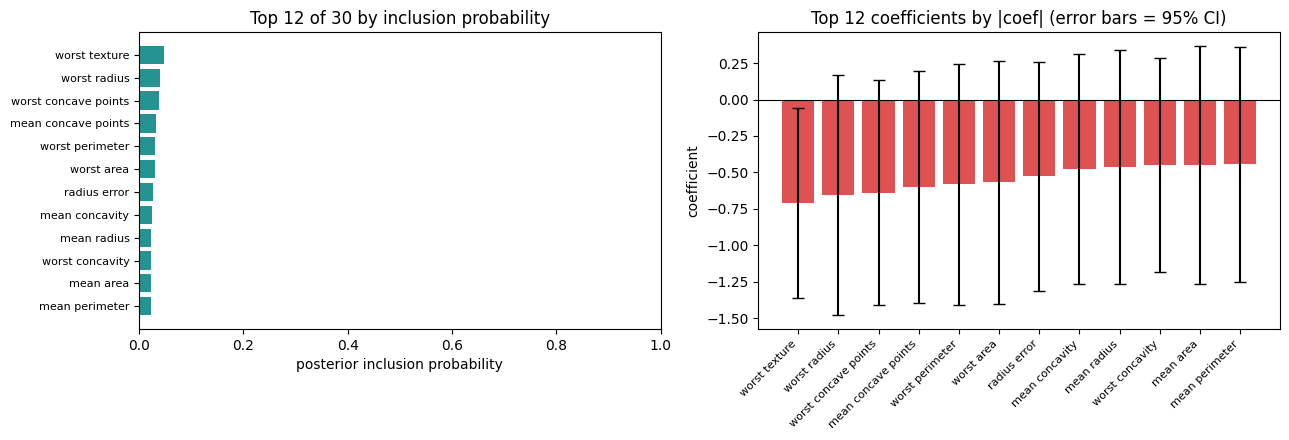

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
clf.plot_inclusion(top_n=12, ax=axes[0])
clf.plot_coefficients(top_n=12, ax=axes[1])
plt.tight_layout()
plt.show()


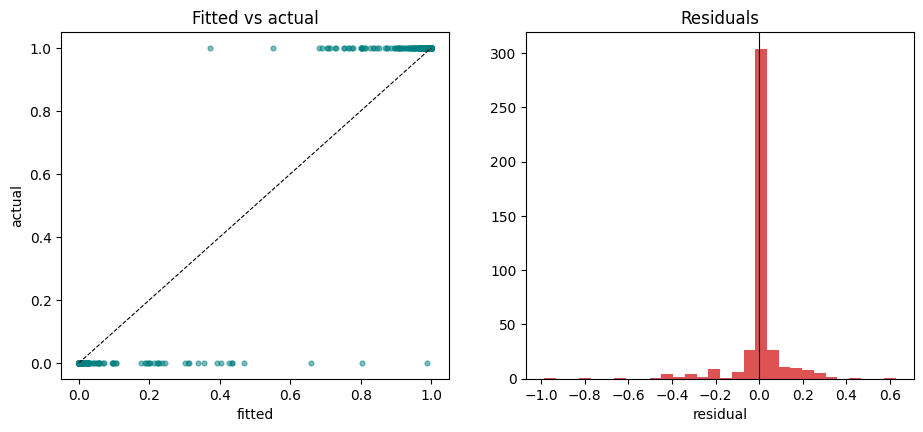

In [5]:
clf.plot_diagnostics()
plt.show()

`plot_diagnostics` gives two views for free: predicted-vs-actual fit quality
on the training data, and (when the fit method iterates, as `"em"` and
`"em_filter"` do) the convergence history — useful for sanity-checking that
the EM loop actually settled rather than being cut off by `max_outer`.


## 3. Evaluate on held-out data

`predict_proba(X_new, return_std=True)` returns a `PredictionResult` — point
estimate plus (if requested) a Monte-Carlo-propagated standard deviation and
credible interval, not just a bare prediction. Compare against a plain
logistic regression baseline on the same standardized features, the natural
apples-to-apples comparison.


In [6]:
pred = clf.predict_proba(X_test_s, return_std=True)
y_pred = (pred.mean >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, pred.mean)
print(f"hierboost (plain):      accuracy={acc:.4f}  AUC={auc:.4f}")

baseline = LogisticRegression(max_iter=5000).fit(X_train_s, y_train)
base_acc = accuracy_score(y_test, baseline.predict(X_test_s))
base_auc = roc_auc_score(y_test, baseline.predict_proba(X_test_s)[:, 1])
print(f"logistic regression:    accuracy={base_acc:.4f}  AUC={base_auc:.4f}")


hierboost (plain):      accuracy=0.9580  AUC=0.9935
logistic regression:    accuracy=0.9580  AUC=0.9952


The credible interval on each prediction (`pred.lower`, `pred.upper`) is worth
looking at directly, not just the point estimate:


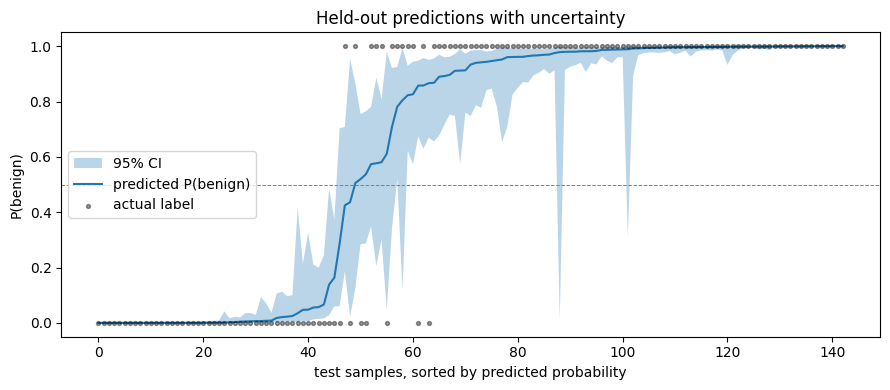

In [7]:
order = np.argsort(pred.mean)
plt.figure(figsize=(9, 4))
plt.fill_between(np.arange(len(order)), pred.lower[order], pred.upper[order],
                  alpha=0.3, label="95% CI")
plt.plot(pred.mean[order], color="C0", label="predicted P(benign)")
plt.scatter(np.arange(len(order)), y_test[order], color="black", s=8, alpha=0.4,
            label="actual label", zorder=3)
plt.axhline(0.5, color="gray", linewidth=0.7, linestyle="--")
plt.xlabel("test samples, sorted by predicted probability")
plt.ylabel("P(benign)")
plt.legend(loc="center left")
plt.title("Held-out predictions with uncertainty")
plt.tight_layout()
plt.show()


## 4. Block-latent decorrelation on the real mean/error/worst triplets

The 30 columns are 10 measurements x 3 statistics of the same underlying quantity --
`mean radius`, `radius error`, `worst radius` are correlated versions of one signal.
`decorrelate="sar"` collapses each such block into one shared latent factor before
running spike-and-slab on the factors instead of the raw columns.

For a **binomial** response, `decorrelate` routes through Chapter 4's discrete/JAX
pipeline, which needs a genuinely meaningful coordinate axis per block (physical
position, a time index) -- our triplets have none, so forcing that combination here
would be a misuse of the API; see
`applications/genomics/genomics_1kg_binomial_latent.py` for a real use of it. For a
**continuous** response, decorrelation uses a closed-form, coordinate-free factor
instead -- so we switch to `HierBoostRegressor` here, predicting `worst area` from the
other 9 measurement blocks (27 features, with the `area` block itself dropped since it
contains the target).


In [8]:
def base_measurement(name):
    return name.replace("mean ", "").replace("worst ", "").replace(" error", "")

target_name = "worst area"
drop_block = {"mean area", "area error", "worst area"}  # the target's own block
keep_idx = [i for i, n in enumerate(feature_names) if n not in drop_block]
X_reg = X[:, keep_idx]
y_reg = X[:, feature_names.index(target_name)]
reg_feature_names = [feature_names[i] for i in keep_idx]

base_names_unique = sorted(set(base_measurement(n) for n in reg_feature_names))
name_to_block = {name: i for i, name in enumerate(base_names_unique)}
block_id = np.array([name_to_block[base_measurement(n)] for n in reg_feature_names])

for i, name in enumerate(base_names_unique):
    members = [reg_feature_names[j] for j in np.where(block_id == i)[0]]
    print(f"block {i} ({name}): {members}")


block 0 (compactness): ['mean compactness', 'compactness error', 'worst compactness']
block 1 (concave points): ['mean concave points', 'concave points error', 'worst concave points']
block 2 (concavity): ['mean concavity', 'concavity error', 'worst concavity']
block 3 (fractal dimension): ['mean fractal dimension', 'fractal dimension error', 'worst fractal dimension']
block 4 (perimeter): ['mean perimeter', 'perimeter error', 'worst perimeter']
block 5 (radius): ['mean radius', 'radius error', 'worst radius']
block 6 (smoothness): ['mean smoothness', 'smoothness error', 'worst smoothness']
block 7 (symmetry): ['mean symmetry', 'symmetry error', 'worst symmetry']
block 8 (texture): ['mean texture', 'texture error', 'worst texture']


In [9]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=0)

x_scaler = StandardScaler().fit(Xr_train)
Xr_train_s, Xr_test_s = x_scaler.transform(Xr_train), x_scaler.transform(Xr_test)
y_scaler = StandardScaler().fit(yr_train.reshape(-1, 1))
yr_train_s = y_scaler.transform(yr_train.reshape(-1, 1)).ravel()
yr_test_s = y_scaler.transform(yr_test.reshape(-1, 1)).ravel()

# `coords` still has to be passed (the API requires it whenever `decorrelate` is
# set) but this branch never actually reads it -- block membership alone drives
# the closed-form factor, so a placeholder index is fine here.
reg_decor = HierBoostRegressor(decorrelate="sar", fit_method="em")
reg_decor.fit(Xr_train_s, yr_train_s,
              coords=np.arange(Xr_train_s.shape[1], dtype=float),
              block_id=block_id, feature_names=reg_feature_names)
print(reg_decor.summary(top_n=9))


HierBoostRegressor summary
Response:             gaussian
Fit method:           em
Decorrelation:        sar  (9 blocks, block_method='threshold')
Observations:         n=426
Features/blocks:      9
------------------------------------------------------------------------
Hyperparameters:      xi0=-2.0  xi1=0.0  kappa=100.0  nu=1.0  lam=1.0
sigma2 (slab var):    0.2141
sigma_y2 (noise var): 0.0715
PPL:                  59.2074
EMBFDR @ gamma=1.0:   0.0000
Selected (centroid):  0 / 9
------------------------------------------------------------------------
Top 9 of 9 features/blocks by inclusion probability:
name                 theta_hat      coef        se   [95% CI]
block5                  0.1704    1.0847    0.1450  [  0.801,   1.369]
block4                  0.0137   -0.1110    0.1516  [ -0.408,   0.186]
block1                  0.0134   -0.0538    0.0498  [ -0.151,   0.044]
block7                  0.0134   -0.0407    0.0196  [ -0.079,  -0.002]
block0                  0.0134    0.0393 

Block names in this summary are `block0`..`block8`, in the same order printed
above. `radius` dominates, unsurprising since tumor area is geometrically
determined almost entirely by radius (area ~ pi * r^2) — a clean sanity check
that the model is finding a real, mechanistically sensible signal rather than
noise.


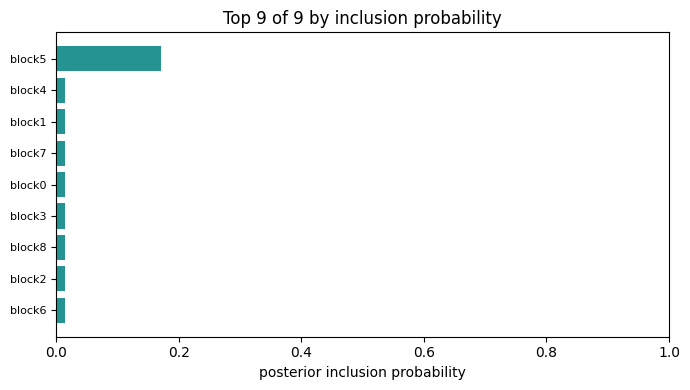

highest-confidence block: block5 (radius)


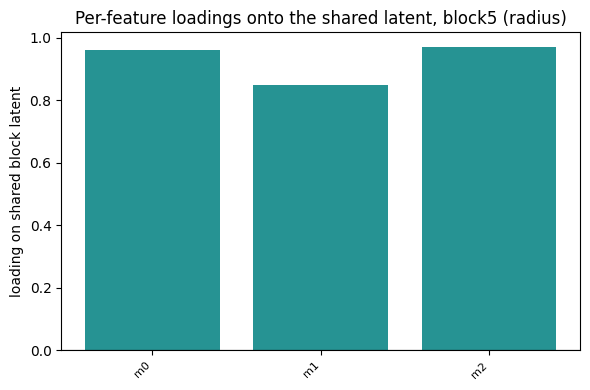

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
reg_decor.plot_inclusion(top_n=9, ax=ax)
plt.tight_layout()
plt.show()

top_block = reg_decor.block_ids_[np.argmax(reg_decor.theta_hat_)]
print(f"highest-confidence block: block{top_block} ({base_names_unique[top_block]})")
reg_decor.plot_latent(block=top_block)
plt.title(f"Per-feature loadings onto the shared latent, block{top_block} ({base_names_unique[top_block]})")
plt.tight_layout()
plt.show()


In [11]:
pred_decor = reg_decor.predict(Xr_test_s, return_std=True)
r2_decor = 1 - np.sum((yr_test_s - pred_decor.mean) ** 2) / np.sum((yr_test_s - yr_test_s.mean()) ** 2)

reg_plain = HierBoostRegressor(fit_method="em")
reg_plain.fit(Xr_train_s, yr_train_s, feature_names=reg_feature_names)
pred_plain = reg_plain.predict(Xr_test_s, return_std=True)
r2_plain = 1 - np.sum((yr_test_s - pred_plain.mean) ** 2) / np.sum((yr_test_s - yr_test_s.mean()) ** 2)

ridge = Ridge(alpha=1.0).fit(Xr_train_s, yr_train_s)
r2_ridge = ridge.score(Xr_test_s, yr_test_s)

print(f"{'model':<28}{'held-out R^2':>14}{'features used':>16}")
print(f"{'hierboost (decorrelated)':<28}{r2_decor:>14.4f}{len(reg_decor.names_):>16d}/9 blocks")
print(f"{'hierboost (plain)':<28}{r2_plain:>14.4f}{X_reg.shape[1]:>16d}/27")
print(f"{'ridge regression':<28}{r2_ridge:>14.4f}{X_reg.shape[1]:>16d}/27")


model                         held-out R^2   features used
hierboost (decorrelated)            0.9551               9/9 blocks
hierboost (plain)                   0.9798              27/27
ridge regression                    0.9797              27/27


On this dataset the raw features are already strong individually, so don't be
surprised if decorrelation trades a little accuracy for a much smaller,
less-redundant feature set — that's the expected trade-off, not a bug. Whether
it's worth it depends on whether you value the smaller, more interpretable
factor set (9 physical measurements instead of 27 near-duplicate columns) over
squeezing out the last point of R^2. The project's broader finding across
several real datasets (finance, fMRI, genomics, text) is that this trade is
worthwhile exactly when blocks have *real but not near-perfect* internal
correlation.


## 5. Other fit methods

- **`fit_method="em_filter"`** — pre-screens down to `min_features` before
  running EM, and (unlike plain `"em"`) actually *drops* columns rather than
  only shrinking them toward zero. Useful whenever you want a genuinely sparse
  feature subset out the other end, or when raw `p` is in the thousands.
- **`fit_method="gibbs"`** — Polya-Gamma Gibbs sampling for the *exact*
  posterior (no Laplace approximation); slower, but `.summary()`'s CIs and
  `.predict(..., return_std=True)`'s uncertainty become genuinely empirical
  rather than approximate.


In [12]:
clf_filter = HierBoostClassifier(fit_method="em_filter", min_features=8, random_state=0)
clf_filter.fit(X_train_s, y_train, feature_names=feature_names)
print(clf_filter.summary(top_n=8))
print(f"\nkept {len(clf_filter.names_)} of {X_train_s.shape[1]} raw features "
      f"(min_features={clf_filter.min_features})")

pred_filter = clf_filter.predict_proba(X_test_s, return_std=True)
acc_filter = accuracy_score(y_test, (pred_filter.mean >= 0.5).astype(int))
auc_filter = roc_auc_score(y_test, pred_filter.mean)
print(f"held-out: accuracy={acc_filter:.4f}  AUC={auc_filter:.4f}")


HierBoostClassifier summary
Response:             binomial (n_trials=1)
Fit method:           em_filter
Decorrelation:        none
Observations:         n=426
Features/blocks:      6 (of 30 raw features)
------------------------------------------------------------------------
Hyperparameters:      xi0=-2.0  xi1=0.0  kappa=100.0  nu=1.0  lam=1.0
sigma2 (slab var):    1.9219
PPL:                  17.0194
EMBFDR @ gamma=1.0:   0.0000
Selected (centroid):  0 / 6
------------------------------------------------------------------------
Top 6 of 6 features/blocks by inclusion probability:
name                 theta_hat      coef        se   [95% CI]
worst concave points    0.0427   -2.1525    0.7151  [ -3.554,  -0.751]
mean concave points     0.0327   -1.8838    0.7755  [ -3.404,  -0.364]
worst radius            0.0319   -1.8585    1.1350  [ -4.083,   0.366]
worst area              0.0297   -1.7802    1.2024  [ -4.137,   0.576]
worst texture           0.0267   -1.6573    0.3468  [ -2.337,  -0

In [13]:
clf_gibbs = HierBoostClassifier(fit_method="gibbs", n_samples=1500, burn_in=500, random_state=0)
clf_gibbs.fit(X_train_s, y_train, feature_names=feature_names)
print(clf_gibbs.summary(top_n=8))

pred_gibbs = clf_gibbs.predict_proba(X_test_s, return_std=True)
acc_gibbs = accuracy_score(y_test, (pred_gibbs.mean >= 0.5).astype(int))
auc_gibbs = roc_auc_score(y_test, pred_gibbs.mean)
print(f"\nheld-out: accuracy={acc_gibbs:.4f}  AUC={auc_gibbs:.4f}")


HierBoostClassifier summary
Response:             binomial (n_trials=1)
Fit method:           gibbs
Decorrelation:        none
Observations:         n=426
Features/blocks:      30
------------------------------------------------------------------------
Hyperparameters:      xi0=-2.0  xi1=0.0  kappa=100.0  nu=1.0  lam=1.0
sigma2 (slab var):    1.0759
PPL:                  8.6676
EMBFDR @ gamma=1.0:   0.0000
Selected (centroid):  0 / 30
------------------------------------------------------------------------
Top 8 of 30 features/blocks by inclusion probability:
name                 theta_hat      coef        se   [95% CI]
radius error            0.4740   -3.6394    3.5882  [-10.672,   3.393]
worst radius            0.4253   -4.2730    5.2158  [-14.496,   5.950]
worst area              0.2920   -2.6968    4.5077  [-11.532,   6.138]
mean concave points     0.2873   -2.1379    2.4119  [ -6.865,   2.589]
worst concave points    0.2800   -1.9858    2.2307  [ -6.358,   2.386]
worst texture    

## 6. Boosting-prior structure (not used in this tutorial)

`fit()` also accepts `group_l`/`group_r`/`group_coords` + `group_relevance` to boost a
feature's prior inclusion probability by proximity to relevant domain groups (genes,
sectors, topics, ...). This dataset has no natural grouping, so it's skipped here -- see
`demos/finance_factor_selection.py` or `applications/genomics/genomics_1kg_demo.py` for
worked examples, and the README's Quickstart for the argument reference.

## Not covered here

- `HierBoostCountRegressor` (Poisson/Negative-Binomial event counts, `.fit(..., offset=...)`)
- `decorrelate="star"` (space x time block-latent) and `marginal="copula"` (heterogeneous
  block marginals)
- `.describe_blocks()`, `.save()`/`.load()`, `hierboost.model_selection.cross_val_score`

See the README's Quickstart/Layout and each module's own docstring for these.

## Cheat sheet

| Question | Where to look |
|---|---|
| Which features/blocks matter? | `theta_hat_` / `.plot_inclusion()` -- as a *relative ranking* |
| How big and which direction? | `.plot_coefficients()` / `.summary()`'s `coef`/CI columns |
| Is the fit converged / well-calibrated? | `.plot_diagnostics()` |
| I want an actual sparse feature subset, not just a ranking | `fit_method="em_filter"` (drops features) |
| Prediction with uncertainty | `.predict(..., return_std=True)` -> `PredictionResult` |
| Many correlated raw features with a **continuous** target? | `decorrelate="sar"` or `"ar1"` for temporal blocks |
| Same, but a **binary/binomial** target? | still `decorrelate="sar"`/`"ar1"`, but needs a real coordinate axis + JAX |
| Domain-relevant groups to boost toward? | `group_l/group_r/group_coords` + `group_relevance` |
| Large `p` (thousands of features)? | `fit_method="em_filter"` |
| Need the exact posterior, not a Laplace approximation? | `fit_method="gibbs"` |
